# XGBoost Modelling Pipeline

## 1. Importing Libraries

In [15]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from dateutil.relativedelta import relativedelta

from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    ConfusionMatrixDisplay,
)

from imblearn.over_sampling import SMOTE
import xgboost as xgb
from scipy.stats import randint, uniform


## 2. Global Configurations

In [16]:
# Which GSADF label column to use as the prediction target:
#   "gsadf_label_95"  →  95% confidence interval (stricter bubble detection)
#   "gsadf_label_90"  →  90% confidence interval (more sensitive)
TARGET_COL = "gsadf_label_90"

# Columns that are NOT model features are dropped before training
NON_FEATURE_COLS = [
    "date",
    "symbol",
    "fear_greed_classification",
    "gsadf_label_95",
    "gsadf_label_90",
]

# String → integer label mapping
LABEL_STR_TO_INT = {
    "Not Bubble"      : 0,
    "Bubble Creation" : 1,
    "Bubble Collapse" : 2,
}
LABEL_MAP   = {v: k for k, v in LABEL_STR_TO_INT.items()}
CLASS_NAMES = ["Not Bubble", "Bubble Creation", "Bubble Collapse"]

# Fear & Greed text → ordinal integer feature
SENTIMENT_ORDINAL = {
    "Extreme Fear" : 0,
    "Fear"         : 1,
    "Neutral"      : 2,
    "Greed"        : 3,
    "Extreme Greed": 4,
}

COLORS     = ["#4C72B0", "#DD8452", "#55A868"]
OUTPUT_DIR = "xgboost_stats"
os.makedirs(OUTPUT_DIR, exist_ok=True)

plt.rcParams.update({
    "figure.dpi"        : 130,
    "axes.spines.top"   : False,
    "axes.spines.right" : False,
    "font.family"       : "monospace",
})

# Rolling-window parameters
TRAIN_MONTHS = 9
VAL_MONTHS   = 3
TEST_MONTHS  = 3
STEP_MONTHS  = 3

COINS = ['ADA', 'BNB', 'BTC', 'DOGE', 'ETH', 'SOL']
SEED  = 42

## 3. Loading & Preprocessing Data

In [17]:
def load_and_preprocess(filepath: str) -> pd.DataFrame:
    """
    Load CSV, encode sentiment, impute missing values, remove infinities,
    and create the lead label (predict TOMORROW's bubble state).
    """
    df = pd.read_csv(filepath, parse_dates=["date"])
    df.sort_values(["date", "symbol"], inplace=True)
    df.reset_index(drop=True, inplace=True)

    print(f"Loaded {len(df):,} rows | Symbols: {sorted(df['symbol'].unique())} "
          f"| {df['date'].min().date()} → {df['date'].max().date()}")

    # Encode fear_greed_classification as ordinal numeric feature
    df["sentiment_ordinal"] = df["fear_greed_classification"].map(SENTIMENT_ORDINAL)
    df["sentiment_ordinal"].fillna(2, inplace=True)

    # Impute missing numeric values (ffill/bfill per coin, then global median)
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    df[numeric_cols] = (
        df.groupby("symbol")[numeric_cols]
        .transform(lambda g: g.ffill().bfill())
    )
    for col in numeric_cols:
        if df[col].isna().any():
            df[col].fillna(df[col].median(), inplace=True)

    # Replace +/- inf with column median
    inf_mask = np.isinf(df[numeric_cols])
    if inf_mask.any(axis=None):
        df[numeric_cols] = df[numeric_cols].replace([np.inf, -np.inf], np.nan)
        for col in numeric_cols:
            if df[col].isna().any():
                df[col].fillna(df[col].median(), inplace=True)

    # Clip extreme outliers
    df[numeric_cols] = df[numeric_cols].clip(lower=-1e15, upper=1e15)

    # Create lead label: each row's target = TOMORROW's bubble state
    LEAD_COL = TARGET_COL + "_lead"
    df[LEAD_COL] = df.groupby("symbol")[TARGET_COL].shift(-1)
    df.dropna(subset=[LEAD_COL], inplace=True)
    df.reset_index(drop=True, inplace=True)

    # Encode string labels → integers
    df["bubble_label"] = df[LEAD_COL].map(LABEL_STR_TO_INT)
    if df["bubble_label"].isna().any():
        raise ValueError(
            f"Unmapped labels found in '{LEAD_COL}': {df[LEAD_COL].unique().tolist()}"
        )
    df["bubble_label"] = df["bubble_label"].astype(int)

    counts = df["bubble_label"].value_counts().sort_index().rename(LABEL_MAP)
    print(f"Label distribution:\n{counts.to_string()}\n")
    return df


def split_features_target(df: pd.DataFrame):
    
    """
    Drop non-feature columns and return (X, y).

    IMPORTANT: Also drops 'label' and 'label_lead' which are pre-computed
    in feature_engineering.ipynb and stored in the CSV. Without this,
    label_lead (the integer-encoded target) leaks into the feature matrix,
    causing wildly inflated metrics in the chronological split.
    This exclusion list mirrors what get_feature_cols() does for the
    rolling-window split.
    """
    
    drop_cols = NON_FEATURE_COLS + [
        "bubble_label",
        TARGET_COL + "_lead",
        "label",       # raw string label column from CSV (if present)
        "label_lead",  # integer-encoded lead label from CSV — prevents data leakage
    ]
    X = df.drop(columns=[c for c in drop_cols if c in df.columns])
    y = df["bubble_label"]

    non_numeric = X.select_dtypes(exclude=[np.number]).columns.tolist()
    if non_numeric:
        raise ValueError(f"Non-numeric columns in X: {non_numeric}")
    return X, y


## 4. Initial Chronological Train/Test Split

The data is split **chronologically**, so all rows before the cutoff date form the training set; all rows from the cutoff onward form the test set. Random splitting would leak future information into training, inflating apparent model accuracy.

In [18]:
def temporal_train_test_split(df: pd.DataFrame, test_ratio: float = 0.2):
    
    """
    Chronological train/test split on the unique date axis.
    All coins are cut at the same calendar date to avoid cross-coin leakage.
    """
    
    unique_dates = sorted(df["date"].unique())
    cutoff_idx   = int(len(unique_dates) * (1 - test_ratio))
    cutoff_date  = unique_dates[cutoff_idx]

    df_train = df[df["date"] <  cutoff_date].copy()
    df_test  = df[df["date"] >= cutoff_date].copy()

    X_train, y_train = split_features_target(df_train)
    X_test,  y_test  = split_features_target(df_test)

    print(f"Cut-off: {pd.Timestamp(cutoff_date).date()} | "
          f"Train: {len(X_train):,} rows | Test: {len(X_test):,} rows")
    return X_train, X_test, y_train, y_test, df_train, df_test

## 5. SMOTE
Due to the extreme difference in the counts of the differemt classes, as suggested we will implement SMOTE for class imbalance handling.

In [19]:
def apply_smote(X_train, y_train, k_neighbors=5, random_state=42, verbose=False):
    """
    Oversample minority classes on the training set only.
    Accepts both numpy arrays and pandas DataFrame/Series.
    k_neighbors is capped at (minority_class_size - 1) to avoid crashes.
    Matches the apply_smote() used in main.ipynb.
    """
    X_arr = np.array(X_train)
    y_arr = np.array(y_train)

    if np.any(np.isinf(X_arr)):
        raise ValueError("Infinity values in X_train - re-run load_and_preprocess().")
    if np.any(np.isnan(X_arr)):
        raise ValueError("NaN values in X_train - re-run load_and_preprocess().")

    if len(np.unique(y_arr)) < 2:
        return X_arr, y_arr

    counts    = np.bincount(y_arr.astype(int), minlength=3)
    min_count = counts[counts > 0].min()
    k = min(k_neighbors, min_count - 1)
    if k < 1:
        return X_arr, y_arr

    smote = SMOTE(random_state=random_state, k_neighbors=k)
    X_res, y_res = smote.fit_resample(X_arr, y_arr)

    if verbose:
        before = pd.Series(y_arr).value_counts().sort_index().rename(LABEL_MAP)
        after  = pd.Series(y_res).value_counts().sort_index().rename(LABEL_MAP)
        print(f"SMOTE  Before: {before.to_dict()}  ->  After: {after.to_dict()}")
    return X_res, y_res

## 6. XGBoost Model

In [20]:
def build_baseline_xgboost(random_state: int = 42) -> xgb.XGBClassifier:
    """
    XGBoost classifier with sensible defaults for 3-class bubble prediction.
    """
    return xgb.XGBClassifier(
        objective        = "multi:softprob",
        num_class        = 3,
        n_estimators     = 300,
        max_depth        = 6,
        learning_rate    = 0.05,
        subsample        = 0.8,
        colsample_bytree = 0.8,
        min_child_weight = 5,
        gamma            = 0.1,
        reg_alpha        = 0.1,
        reg_lambda       = 1.0,
        eval_metric      = "mlogloss",
        random_state     = random_state,
        n_jobs           = -1,
    )


def hyperparameter_tuning(
    X_train: np.ndarray,
    y_train: np.ndarray,
    n_iter:       int = 40,
    cv_folds:     int = 5,
    random_state: int = 42,
) -> xgb.XGBClassifier:
    """
    Randomised search over XGBoost hyperparameters.
    Scored by macro F1 which treats all three bubble classes equally.
    Uses StratifiedKFold to ensure all classes appear in every fold.
    """
    param_distributions = {
        "n_estimators"     : randint(100, 600),
        "max_depth"        : randint(3, 10),
        "learning_rate"    : uniform(0.01, 0.2),
        "subsample"        : uniform(0.6, 0.4),
        "colsample_bytree" : uniform(0.5, 0.5),
        "min_child_weight" : randint(1, 15),
        "gamma"            : uniform(0, 0.5),
        "reg_alpha"        : uniform(0, 1.0),
        "reg_lambda"       : uniform(0.5, 2.0),
    }

    base_model = xgb.XGBClassifier(
        objective    = "multi:softprob",
        num_class    = 3,
        eval_metric  = "mlogloss",
        random_state = random_state,
        n_jobs       = -1,
    )

    cv = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=random_state)

    search = RandomizedSearchCV(
        estimator           = base_model,
        param_distributions = param_distributions,
        n_iter              = n_iter,
        scoring             = "f1_macro",
        cv                  = cv,
        verbose             = 0,
        random_state        = random_state,
        n_jobs              = -1,
        refit               = True,
    )

    search.fit(X_train, y_train)
    print(f"  Best CV macro-F1 : {search.best_score_:.4f}")
    return search.best_estimator_


def train_model(
    X_train: np.ndarray,
    y_train: np.ndarray,
    model:   xgb.XGBClassifier,
    val_ratio: float = 0.1,
    random_state: int = 42,
) -> xgb.XGBClassifier:
    """
    Fit XGBoost with early stopping (30 rounds patience).

    A small stratified validation split is carved from the TRAINING data
    so that the test set is never seen during fitting.
    """
    from sklearn.model_selection import train_test_split
    X_tr, X_val, y_tr, y_val = train_test_split(
        X_train, y_train,
        test_size    = val_ratio,
        stratify     = y_train,
        random_state = random_state,
    )
    model.set_params(early_stopping_rounds=30)
    model.fit(
        X_tr, y_tr,
        eval_set = [(X_val, y_val)],
        verbose  = False,
    )
    return model


## 7. Evaluation & Visualisations

In [21]:
def evaluate_model(
    model:      xgb.XGBClassifier,
    X_test:     pd.DataFrame,
    y_test:     pd.Series,
    model_name: str = "XGBoost",
) -> dict:
    
    """
    Compute per-class Precision, Recall, F1 plus Macro F1, Weighted F1,
    and ROC-AUC. Prints a clean classification report.

    Handles the case where the test set does not contain all 3 classes
    (common in per-coin evaluation) by:
      - Padding per-class metric arrays to length 3 with zeros for absent classes
      - Computing ROC-AUC only over the classes that are present in y_test, or reporting NaN when fewer than 2 classes are present
    """
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)      # always shape (n_samples, 3)

    present_classes = sorted(y_test.unique())   # which class integers appear in y_test
    n_present       = len(present_classes)

    # Per-class metrics which are padded to length 3 
    # sklearn returns one value per class that actually appears in y_test/y_pred.
    def _padded(metric_fn, **kwargs):
        raw = metric_fn(y_test, y_pred, average=None, zero_division=0,
                        labels=[0, 1, 2], **kwargs)
        return raw  # already length-3, one entry per class

    precision_pc = _padded(precision_score)
    recall_pc    = _padded(recall_score)
    f1_pc        = _padded(f1_score)

    f1_macro     = f1_score(       y_test, y_pred, average="macro",    zero_division=0)
    f1_weighted  = f1_score(       y_test, y_pred, average="weighted", zero_division=0)
    prec_macro   = precision_score(y_test, y_pred, average="macro",    zero_division=0)
    rec_macro    = recall_score(   y_test, y_pred, average="macro",    zero_division=0)

    # ROC-AUC - only computable when >= 2 classes are present 
    # roc_auc_score(multi_class="ovr") requires the number of unique classes in y_true to equal the number of columns in y_score. 
    if n_present >= 2:
        y_prob_present = y_prob[:, present_classes]   # keep only relevant columns
        if n_present == 3:
            # All classes present - standard multiclass OvR
            roc_auc = roc_auc_score(
                y_test, y_prob_present, multi_class="ovr", average="weighted")
        else:
            # Exactly 2 classes present - binary ROC-AUC on the positive column
            # Re-label y_test to 0/1 for the two present classes
            y_bin     = (y_test == present_classes[1]).astype(int)
            roc_auc   = roc_auc_score(y_bin, y_prob_present[:, 1])
    else:
        # Only 1 class in test set - ROC-AUC is undefined
        roc_auc = float("nan")

    print("=" * 60)
    print(f"  {model_name}")
    if n_present < 3:
        print(f"  ⚠ Only {n_present} class(es) in test set: "
              f"{[CLASS_NAMES[c] for c in present_classes]}")
    print("=" * 60)
    print(classification_report(
        y_test, y_pred, target_names=CLASS_NAMES, digits=4,
        zero_division=0, labels=[0, 1, 2]))
    roc_str = f"{roc_auc:.4f}" if not np.isnan(roc_auc) else "N/A"
    print(f"  Macro F1   : {f1_macro:.4f}   |   "
          f"Weighted F1 : {f1_weighted:.4f}   |   "
          f"ROC-AUC : {roc_str}")
    print("=" * 60 + "\n")

    return {
        "model_name"         : model_name,
        "y_pred"             : y_pred,
        "y_prob"             : y_prob,
        "precision_per_class": precision_pc,
        "recall_per_class"   : recall_pc,
        "f1_per_class"       : f1_pc,
        "f1_macro"           : f1_macro,
        "f1_weighted"        : f1_weighted,
        "precision_macro"    : prec_macro,
        "recall_macro"       : rec_macro,
        "roc_auc"            : roc_auc,
    }

# Plotting the statistics 
def plot_confusion_matrix(y_test, y_pred, model_name: str = "XGBoost"):

    """
    Normalised confusion matrix (values = proportions of true class).
    """
    cm   = confusion_matrix(y_test, y_pred, normalize="true", labels=[0, 1, 2])
    fig, ax = plt.subplots(figsize=(7, 5))
    ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES).plot(
        ax=ax, colorbar=True, cmap="Blues", values_format=".2f")
    ax.set_title(f"Confusion Matrix — {model_name}", fontsize=12, pad=10)
    plt.tight_layout()
    fname = os.path.join(OUTPUT_DIR, f"cm_{model_name.replace(' ', '_')}.png")
    plt.savefig(fname, dpi=130)
    plt.show()


def plot_per_class_metrics(results: dict):

    """
    Grouped bar chart: Precision / Recall / F1 per bubble class.
    """
    metrics = {
        "Precision": results["precision_per_class"],
        "Recall"   : results["recall_per_class"],
        "F1-Score" : results["f1_per_class"],
    }
    x, width = np.arange(len(CLASS_NAMES)), 0.25
    fig, ax = plt.subplots(figsize=(9, 5))
    for i, (name, vals) in enumerate(metrics.items()):
        bars = ax.bar(x + i * width, vals, width, label=name, color=COLORS[i], alpha=0.85)
        ax.bar_label(bars, fmt="%.2f", padding=3, fontsize=8)
    ax.set_xticks(x + width)
    ax.set_xticklabels(CLASS_NAMES)
    ax.set_ylim(0, 1.15)
    ax.set_ylabel("Score")
    ax.set_title(f"Per-Class Metrics — {results['model_name']}", fontsize=12)
    ax.legend(loc="upper right")
    plt.tight_layout()
    fname = os.path.join(OUTPUT_DIR,
                         f"metrics_{results['model_name'].replace(' ', '_')}.png")
    plt.savefig(fname, dpi=130)
    plt.show()


def plot_feature_importance(model: xgb.XGBClassifier, model_name: str = "XGBoost",
                             top_n: int = 20):
    
    """
    Horizontal bar chart of top features ranked by gain.
    """
    importance = model.get_booster().get_score(importance_type="gain")
    imp_df = (
        pd.DataFrame.from_dict(importance, orient="index", columns=["Gain"])
        .rename_axis("Feature").reset_index()
        .sort_values("Gain", ascending=False)
        .head(top_n)
    )
    fig, ax = plt.subplots(figsize=(8, top_n * 0.38 + 1))
    ax.barh(imp_df["Feature"][::-1], imp_df["Gain"][::-1], color="#4C72B0", alpha=0.85)
    ax.set_xlabel("Gain")
    ax.set_title(f"Top {top_n} Features by Gain — {model_name}", fontsize=12)
    plt.tight_layout()
    fname = os.path.join(OUTPUT_DIR,
                         f"feature_importance_{model_name.replace(' ', '_')}.png")
    plt.savefig(fname, dpi=130)
    plt.show()


def plot_class_distribution(y_before, y_after, title_suffix: str = ""):

    """
    Side-by-side bar charts: class counts before vs after SMOTE.
    """
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    for ax, y, title in zip(axes,
                             [y_before, y_after],
                             ["Before SMOTE", "After SMOTE"]):
        counts = pd.Series(y).value_counts().sort_index().rename(LABEL_MAP)
        ax.bar(range(len(counts)), counts.values, color=COLORS, alpha=0.85, edgecolor="white")
        ax.set_xticks(range(len(counts)))
        ax.set_xticklabels(counts.index, rotation=10, ha="right")
        ax.set_title(f"{title}{title_suffix}", fontsize=11)
        ax.set_ylabel("Count")
        for i, v in enumerate(counts.values):
            ax.text(i, v + max(counts.values) * 0.01, str(v), ha="center", fontsize=9)
    plt.tight_layout()
    safe = title_suffix.strip().replace(" ", "_").replace("/", "")
    fname = os.path.join(OUTPUT_DIR, f"smote_distribution{safe}.png")
    plt.savefig(fname, dpi=130)
    plt.show()


# Functions for exporting results to CSV and plotting metrics are defined below.
def export_metrics_to_csv(results_list: list, filepath: str = None):

    """
    Write per-class and aggregate metrics for all models to CSV.
    """
    if filepath is None:
        filepath = os.path.join(OUTPUT_DIR, "model_metrics_summary.csv")
    rows = []
    for r in results_list:
        for i, cls in enumerate(CLASS_NAMES):
            rows.append({
                "Model"    : r["model_name"],
                "Class"    : cls,
                "Precision": round(r["precision_per_class"][i], 4),
                "Recall"   : round(r["recall_per_class"][i],    4),
                "F1-Score" : round(r["f1_per_class"][i],        4),
            })
        roc_val = r["roc_auc"]
        roc_display = round(roc_val, 4) if not np.isnan(roc_val) else "N/A"
        for label, val in [
            ("-- MACRO AVG --",          r["f1_macro"]),
            ("-- WEIGHTED AVG (F1) --",  r["f1_weighted"]),
        ]:
            rows.append({"Model": r["model_name"], "Class": label,
                         "Precision": "--", "Recall": "--",
                         "F1-Score": round(val, 4)})
        rows.append({"Model": r["model_name"], "Class": "-- ROC-AUC (weighted) --",
                     "Precision": "--", "Recall": "--", "F1-Score": roc_display})
    df_out = pd.DataFrame(rows)
    df_out.to_csv(filepath, index=False)
    print(f"Metrics saved → {filepath}")
    return df_out


## 8. Cross-Asset Analysis
We further train xgboost models for each individual coin to validate the validity of the theory given. 


In [22]:
def evaluate_per_coin(model: xgb.XGBClassifier,
                      df_test: pd.DataFrame,
                      model_name: str = "Global Model") -> pd.DataFrame:
    
    """
    Evaluate a trained model separately for each coin in the test set.
    Returns a DataFrame of per-coin F1 scores.
    """
    rows = []
    for coin in sorted(df_test["symbol"].unique()):
        subset = df_test[df_test["symbol"] == coin].copy()
        X_coin, y_coin = split_features_target(subset)
        y_pred = model.predict(X_coin)

        f1s = f1_score(y_coin, y_pred, average=None, zero_division=0, labels=[0, 1, 2])
        f1s = np.pad(f1s, (0, max(0, 3 - len(f1s))))
        rows.append({
            "Coin"             : coin,
            "F1 Not Bubble"    : round(f1s[0], 4),
            "F1 Bubble Creat." : round(f1s[1], 4),
            "F1 Bubble Coll."  : round(f1s[2], 4),
            "F1 Weighted"      : round(
                f1_score(y_coin, y_pred, average="weighted", zero_division=0), 4),
        })

    df_coins = pd.DataFrame(rows)
    df_coins.to_csv(
        os.path.join(OUTPUT_DIR, f"per_coin_f1_{model_name.replace(' ', '_')}.csv"),
        index=False)
    return df_coins


def train_per_coin_models(
    df: pd.DataFrame,
    test_ratio:   float = 0.2,
    n_iter:       int   = 40,
    cv_folds:     int   = 5,
    random_state: int   = 42,
) -> tuple:
    
    """
    Train a separate hyperparameter-tuned XGBoost model for each coin.

    For each symbol the function:
      1. Filters the data to that coin only
      2. Performs a chronological train/test split
      3. Applies SMOTE to the training set
      4. Runs hyperparameter tuning (macro F1 scoring)
      5. Trains the best model with early stopping
      6. Evaluates on the coin's test set

    Returns
    -------
    per_coin_models  : dict  {symbol → fitted XGBClassifier}
    per_coin_results : dict  {symbol → evaluate_model() result dict}
    summary_df       : pd.DataFrame  with per-coin metrics
    """
    coins            = sorted(df["symbol"].unique())
    per_coin_models  = {}
    per_coin_results = {}
    summary_rows     = []

    for coin in coins:
        print(f"\n{'-'*55}")
        print(f"  Training per-coin model : {coin}")
        print(f"{'-'*55}")

        coin_df = df[df["symbol"] == coin].copy().reset_index(drop=True)

        # Chronological split within this coin's data
        unique_dates = sorted(coin_df["date"].unique())
        cutoff_idx   = int(len(unique_dates) * (1 - test_ratio))
        cutoff_date  = unique_dates[cutoff_idx]

        train_df = coin_df[coin_df["date"] <  cutoff_date].copy()
        test_df  = coin_df[coin_df["date"] >= cutoff_date].copy()

        X_train, y_train = split_features_target(train_df)
        X_test,  y_test  = split_features_target(test_df)

        print(f"  Train: {len(X_train):,}  |  Test: {len(X_test):,}  "
              f"| Cut-off: {pd.Timestamp(cutoff_date).date()}")

        # Skip coin if any class is absent from training set (can't SMOTE or tune)
        if y_train.nunique() < 3:
            print(f"  Skipping {coin}: fewer than 3 classes in training set.")
            continue

        # SMOTE
        X_tr_res, y_tr_res = apply_smote(X_train, y_train,
                                          random_state=random_state, verbose=True)

        # Hyperparameter tuning
        model = hyperparameter_tuning(X_tr_res, y_tr_res,
                                       n_iter=n_iter, cv_folds=cv_folds,
                                       random_state=random_state)

        # Train with early stopping on a held-out val split (not the test set)
        model = train_model(X_tr_res, y_tr_res, model)

        # Evaluate
        result = evaluate_model(model, X_test, y_test, f"Per-Coin: {coin}")

        per_coin_models[coin]  = model
        per_coin_results[coin] = result

        for i, cls in enumerate(CLASS_NAMES):
            summary_rows.append({
                "Coin"      : coin,
                "Class"     : cls,
                "Precision" : round(result["precision_per_class"][i], 4),
                "Recall"    : round(result["recall_per_class"][i],    4),
                "F1-Score"  : round(result["f1_per_class"][i],        4),
            })
        summary_rows.append({
            "Coin": coin, "Class": "-- MACRO AVG --",
            "Precision": "--", "Recall": "--",
            "F1-Score": round(result["f1_macro"], 4),
        })

    summary_df = pd.DataFrame(summary_rows)
    summary_df.to_csv(
        os.path.join(OUTPUT_DIR, "per_coin_model_metrics.csv"), index=False)
    print(f"\nPer-coin model metrics saved -> {OUTPUT_DIR}/per_coin_model_metrics.csv")
    return per_coin_models, per_coin_results, summary_df


def plot_per_coin_heatmap(df_coins: pd.DataFrame, title: str = ""):
    
    """
    Heatmap of F1 scores across coins and bubble states.
    Expects a DataFrame with columns: "Coin", "F1 Not Bubble", "F1 Bubble Creat.", "F1 Bubble Coll."
    """
    heat_df = df_coins.set_index("Coin")[
        ["F1 Not Bubble", "F1 Bubble Creat.", "F1 Bubble Coll."]
    ]
    fig, ax = plt.subplots(figsize=(7, len(df_coins) * 0.6 + 1.5))
    sns.heatmap(heat_df, annot=True, fmt=".2f", cmap="YlGnBu",
                linewidths=0.5, ax=ax, vmin=0, vmax=1)
    ax.set_title(f"F1 Score by Coin & Bubble State{(' - ' + title) if title else ''}",
                 fontsize=12)
    plt.tight_layout()
    safe = title.replace(" ", "_")
    fname = os.path.join(OUTPUT_DIR, f"per_coin_heatmap_{safe}.png")
    plt.savefig(fname, dpi=130)
    plt.show()


def plot_per_coin_model_comparison(per_coin_results: dict):
    
    """
    Bar chart comparing macro F1 of each coin's dedicated model.
    """
    coins  = list(per_coin_results.keys())
    f1s    = [per_coin_results[c]["f1_macro"] for c in coins]

    fig, ax = plt.subplots(figsize=(8, 4))
    bars = ax.bar(coins, f1s, color="#4C72B0", alpha=0.85, edgecolor="white")
    ax.bar_label(bars, fmt="%.3f", padding=3, fontsize=9)
    ax.set_ylim(0, 1.1)
    ax.set_ylabel("Macro F1")
    ax.set_title("Per-Coin Model - Macro F1 by Coin", fontsize=12)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "per_coin_macro_f1_bar.png"), dpi=130)
    plt.show()

## 9. Main Pipeline

Run models trained with 2 different splits:
- **Split 1 - Rolling Window Split**: The XGBoost models are trained on a 9 month/3 month/3 month train/test/validate split
- **Split 2 - Chronological Split**: The XGBoost models are trained on a 80-20 train/test split


Runs two model types in sequence, for each train/test split:
- **Model 1 — Global**: one XGBoost model trained on all coins together
- **Model 2 — Per-Coin**: one separate XGBoost model per coin

## 9.1 Split 1: Rolling Window Split

In [23]:
# Rolling-window helpers

def generate_windows(date_min, date_max):
    """Yield (train_start, val_start, test_start, test_end) tuples."""
    train_start = date_min
    while True:
        val_start  = train_start + relativedelta(months=TRAIN_MONTHS)
        test_start = val_start   + relativedelta(months=VAL_MONTHS)
        test_end   = test_start  + relativedelta(months=TEST_MONTHS)
        if test_end > date_max:
            break
        yield train_start, val_start, test_start, test_end
        train_start += relativedelta(months=STEP_MONTHS)


def split_window(df, train_start, val_start, test_start, test_end):
    tr = df[(df['date'] >= train_start) & (df['date'] < val_start)]
    va = df[(df['date'] >= val_start)   & (df['date'] < test_start)]
    te = df[(df['date'] >= test_start)  & (df['date'] < test_end)]
    return tr, va, te


def get_feature_cols(df):
    """Return feature columns, excluding all non-feature columns."""
    extra = {'label', 'label_lead', 'bubble_label',
             TARGET_COL + '_lead', TARGET_COL}
    drop  = set(NON_FEATURE_COLS) | extra
    return [c for c in df.columns if c not in drop and df[c].dtype != object]


def evaluate_fold(model, X_te, y_te):
    """Compute per-class and aggregate metrics for one test fold."""
    y_pred = model.predict(X_te)

    if len(y_pred.shape) > 1:
        y_pred = np.argmax(y_pred, axis=1)
        
    return {
        'macro_f1'     : f1_score(y_te, y_pred, average='macro',    zero_division=0),
        'weighted_f1'  : f1_score(y_te, y_pred, average='weighted', zero_division=0),
        'accuracy'     : float(np.mean(np.array(y_pred) == np.array(y_te))),
        'f1_not_bubble': f1_score(y_te, y_pred, labels=[0], average='macro', zero_division=0),
        'f1_creation'  : f1_score(y_te, y_pred, labels=[1], average='macro', zero_division=0),
        'f1_collapse'  : f1_score(y_te, y_pred, labels=[2], average='macro', zero_division=0),
    }


def build_xgb_rw(tune=False, X_tr=None, y_tr=None, X_va=None, y_va=None):
    """
    Build and fit an XGBoost classifier for one rolling-window fold.
    If tune=True, runs RandomizedSearchCV (slow).
    Uses early stopping against the provided validation set.
    """
    if tune and X_tr is not None:
        model = hyperparameter_tuning(X_tr, y_tr, n_iter=40, cv_folds=5)
    else:
        model = build_baseline_xgboost(random_state=SEED)

    model.set_params(early_stopping_rounds=30)
    model.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], verbose=False)
    return model

In [24]:
# Load raw data (same file as the static pipeline above)
FILEPATH = "data/df_features_with_labels.csv"
df_rw = pd.read_csv(FILEPATH, parse_dates=['date'])
df_rw.sort_values(['date', 'symbol'], inplace=True)
df_rw.reset_index(drop=True, inplace=True)

# Use the pre-computed integer label_lead column (created in feature_engineering.ipynb).
if 'label_lead' not in df_rw.columns:
    df_rw['label_lead'] = (
        df_rw.groupby('symbol')[TARGET_COL]
             .shift(-1)
             .map(LABEL_STR_TO_INT)
    )
df_rw.dropna(subset=['label_lead'], inplace=True)
df_rw['label_lead'] = df_rw['label_lead'].astype(int)

TARGET_RW    = 'label_lead'
FEATURE_COLS = get_feature_cols(df_rw)

# One-hot coin dummies for the global model
coin_dummies        = pd.get_dummies(df_rw['symbol'], prefix='coin').astype(float)
df_rw_global        = pd.concat([df_rw, coin_dummies], axis=1)
FEATURE_COLS_GLOBAL = FEATURE_COLS + list(coin_dummies.columns)

DATE_MIN    = df_rw['date'].min()
DATE_MAX    = df_rw['date'].max()
all_windows = list(generate_windows(DATE_MIN, DATE_MAX))
print(f"Total rolling windows : {len(all_windows)}")
print(f"  First : {all_windows[0][0].date()} -> {all_windows[0][3].date()}")
print(f"  Last  : {all_windows[-1][0].date()} -> {all_windows[-1][3].date()}")
print(f"Per-coin feature cols : {len(FEATURE_COLS)}")
print(f"Global feature cols   : {len(FEATURE_COLS_GLOBAL)}")

XGB_TUNE_RW = False  

Total rolling windows : 22
  First : 2018-05-01 -> 2019-08-01
  Last  : 2023-08-01 -> 2024-11-01
Per-coin feature cols : 133
Global feature cols   : 139


In [25]:
rw_results = []

# Per-window evaluation loop for each coin separately 
for coin in COINS:
    coin_df      = df_rw[df_rw['symbol'] == coin].copy()
    coin_windows = list(generate_windows(coin_df['date'].min(), coin_df['date'].max()))
    print(f"\n{coin}: {len(coin_windows)} windows")

    for fold, window in enumerate(coin_windows):
        tr, va, te = split_window(coin_df, *window)
        if len(tr) < 30 or len(te) < 5:
            continue

        X_tr = np.nan_to_num(tr[FEATURE_COLS].values, nan=0.0)
        X_va = np.nan_to_num(va[FEATURE_COLS].values, nan=0.0)
        X_te = np.nan_to_num(te[FEATURE_COLS].values, nan=0.0)
        y_tr = tr[TARGET_RW].values
        y_va = va[TARGET_RW].values
        y_te = te[TARGET_RW].values

        if not set([0, 1, 2]).issubset(set(np.unique(y_tr))):
            continue

        X_tr_sm, y_tr_sm = apply_smote(X_tr, y_tr, random_state=SEED)
        model   = build_xgb_rw(tune=XGB_TUNE_RW,
                                X_tr=X_tr_sm, y_tr=y_tr_sm,
                                X_va=X_va,    y_va=y_va)
        metrics = evaluate_fold(model, X_te, y_te)

        ts, vs, tes_, tee = window
        rw_results.append({
            'model': 'XGBoost', 'scope': 'per_coin', 'coin': coin, 'fold': fold,
            'train_start': ts.date(), 'test_end': tee.date(),
            **metrics,
        })

print("\n--- XGBoost per-coin rolling-window complete ---")

# Global rolling-window 
print("\nGlobal model rolling windows:")
for fold, window in enumerate(all_windows):
    tr, va, te = split_window(df_rw_global, *window)
    if len(tr) < 30 or len(te) < 5:
        continue

    X_tr = np.nan_to_num(tr[FEATURE_COLS_GLOBAL].values, nan=0.0)
    X_va = np.nan_to_num(va[FEATURE_COLS_GLOBAL].values, nan=0.0)
    X_te = np.nan_to_num(te[FEATURE_COLS_GLOBAL].values, nan=0.0)
    y_tr = tr[TARGET_RW].values
    y_va = va[TARGET_RW].values
    y_te = te[TARGET_RW].values

    if not set([0, 1, 2]).issubset(set(np.unique(y_tr))):
        continue

    X_tr_sm, y_tr_sm = apply_smote(X_tr, y_tr, random_state=SEED)
    model   = build_xgb_rw(tune=XGB_TUNE_RW,
                            X_tr=X_tr_sm, y_tr=y_tr_sm,
                            X_va=X_va,    y_va=y_va)
    metrics = evaluate_fold(model, X_te, y_te)

    ts, vs, tes_, tee = window
    rw_results.append({
        'model': 'XGBoost', 'scope': 'global', 'coin': 'ALL', 'fold': fold,
        'train_start': ts.date(), 'test_end': tee.date(),
        **metrics,
    })

print("\n--- XGBoost global rolling-window complete ---")



ADA: 22 windows

BNB: 22 windows

BTC: 22 windows

DOGE: 17 windows

ETH: 22 windows

SOL: 13 windows

--- XGBoost per-coin rolling-window complete ---

Global model rolling windows:

--- XGBoost global rolling-window complete ---


In [26]:
# Calcuate summary statistics and export results to CSV
METRIC_COLS = ['macro_f1', 'weighted_f1', 'accuracy',
               'f1_not_bubble', 'f1_creation', 'f1_collapse']

df_rw_res = pd.DataFrame(rw_results)

# Mean +/- std across all folds
rw_summary = (
    df_rw_res
    .groupby(['model', 'scope'])[METRIC_COLS]
    .agg(['mean', 'std'])
    .round(4)
)
print("=== Rolling-Window Summary (mean +/- std across folds) ===")
print(rw_summary.to_string())

# Ranked by mean Macro F1 — matches main.ipynb table format
rw_summary_mean = (
    df_rw_res
    .groupby(['model', 'scope'])[METRIC_COLS]
    .mean()
    .round(4)
    .sort_values('macro_f1', ascending=False)
    .reset_index()
)
print("\n=== Ranked by Mean Macro F1 ===")
print(rw_summary_mean.to_string(index=False))

# Per-coin breakdown (per-coin scope only)
rw_per_coin = (
    df_rw_res[df_rw_res['scope'] == 'per_coin']
    .groupby('coin')[METRIC_COLS]
    .mean()
    .round(4)
    .reset_index()
    .sort_values('macro_f1', ascending=False)
)
print("\n=== Per-Coin Mean Metrics (Rolling) ===")
print(rw_per_coin.to_string(index=False))

# Save results
os.makedirs(OUTPUT_DIR, exist_ok=True)
df_rw_res.to_csv(
    os.path.join(OUTPUT_DIR, 'rolling_window_results_xgboost.csv'), index=False)
rw_summary_mean.to_csv(
    os.path.join(OUTPUT_DIR, 'rolling_window_summary_xgboost.csv'), index=False)
print(f"\nResults saved to {OUTPUT_DIR}/")

=== Rolling-Window Summary (mean +/- std across folds) ===
                 macro_f1         weighted_f1         accuracy         f1_not_bubble         f1_creation         f1_collapse        
                     mean     std        mean     std     mean     std          mean     std        mean     std        mean     std
model   scope                                                                                                                       
XGBoost global     0.4430  0.2308      0.6864  0.2823   0.6916  0.2972        0.7483  0.2823      0.1367  0.2166      0.0965  0.1620
        per_coin   0.4355  0.3238      0.6113  0.3709   0.6189  0.3647        0.5505  0.4307      0.1649  0.3241      0.1247  0.2485

=== Ranked by Mean Macro F1 ===
  model    scope  macro_f1  weighted_f1  accuracy  f1_not_bubble  f1_creation  f1_collapse
XGBoost   global    0.4430       0.6864    0.6916         0.7483       0.1367       0.0965
XGBoost per_coin    0.4355       0.6113    0.6189         0.5

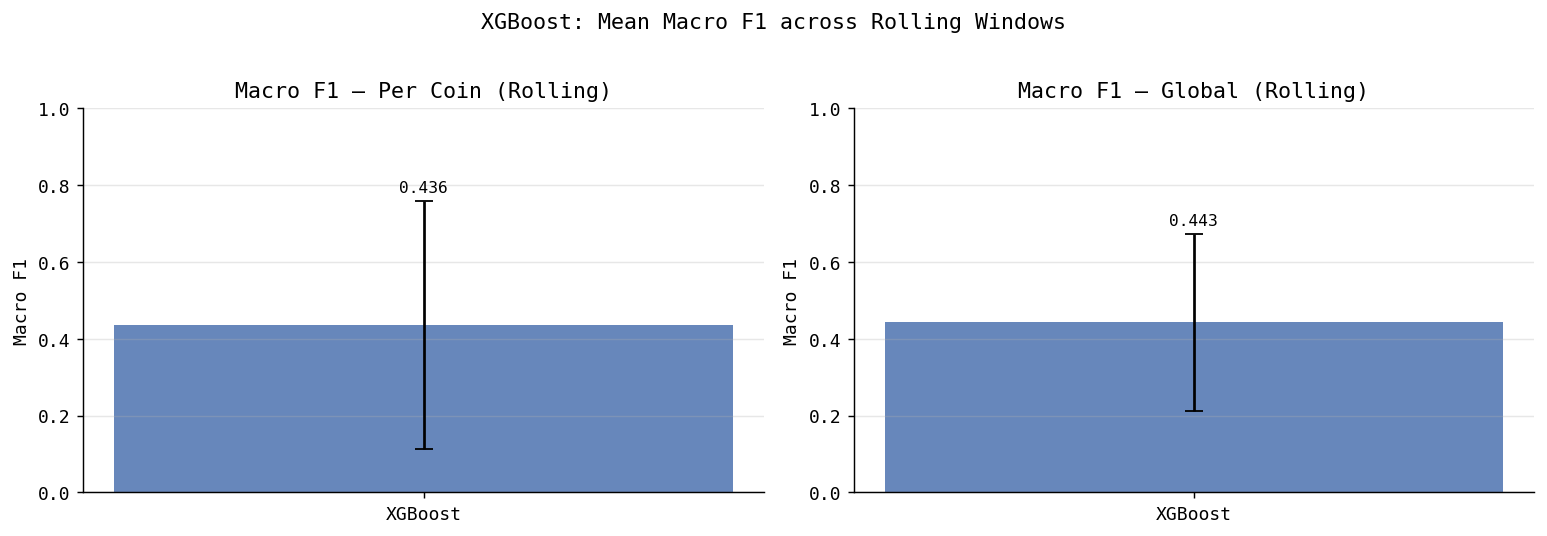

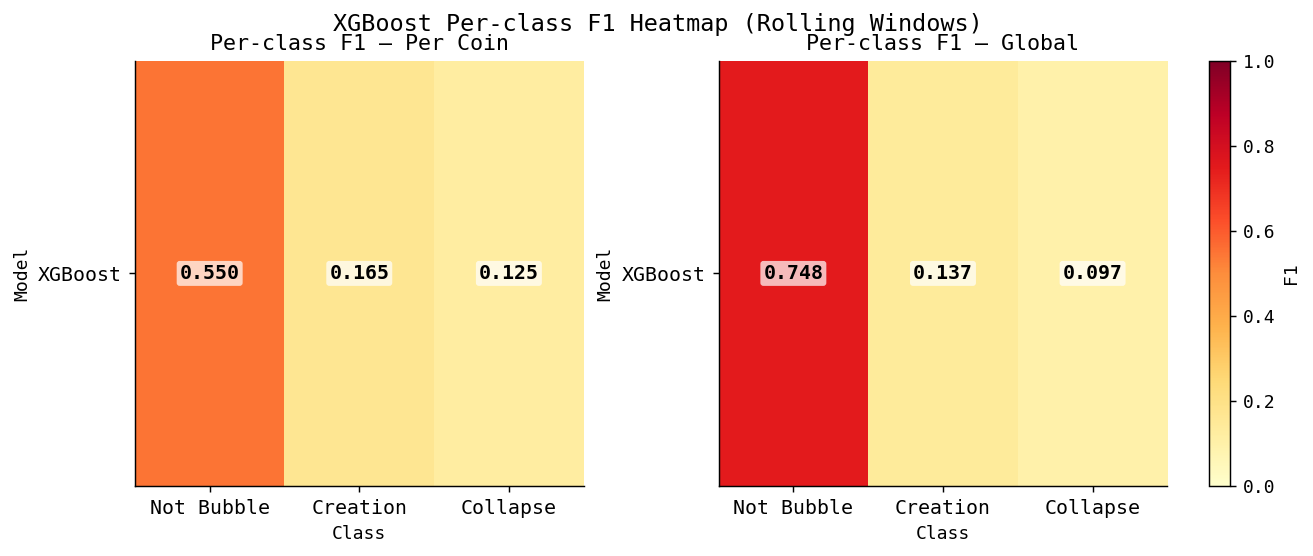

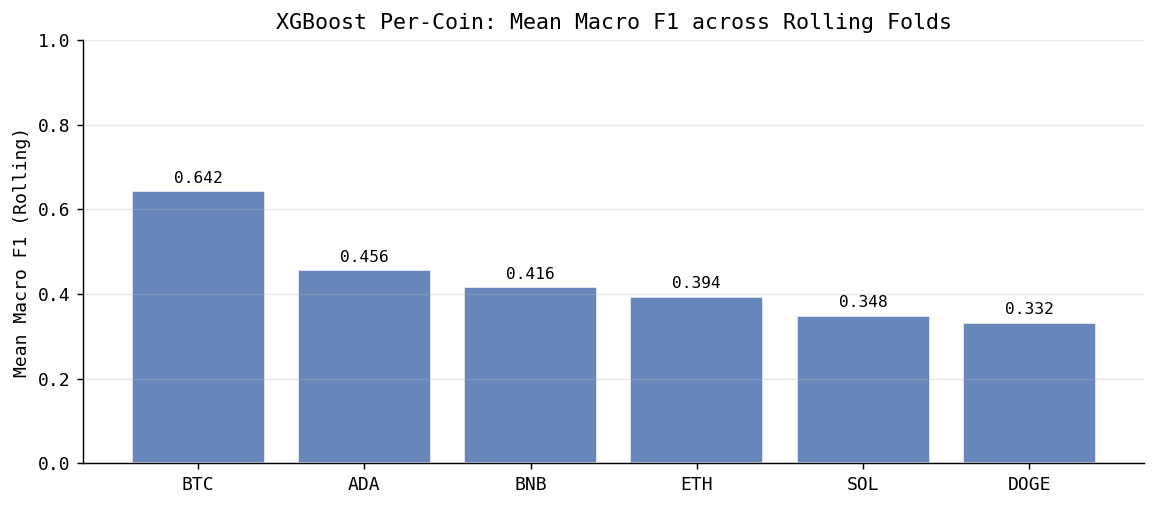

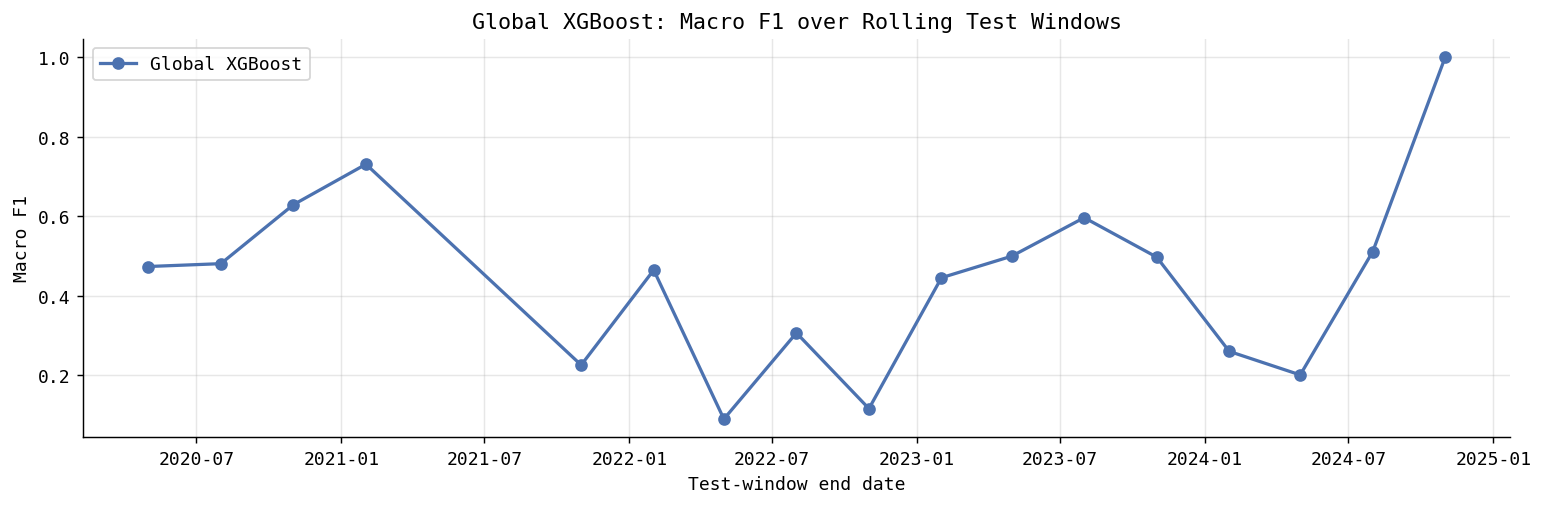

In [27]:
# Printing visualisations of the rolling-window results. These include:

# Bar chart: mean Macro F1 per scope 
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, scope in zip(axes, ['per_coin', 'global']):
    sub  = df_rw_res[df_rw_res['scope'] == scope]
    grp  = sub.groupby('model')['macro_f1'].agg(['mean', 'std']).reset_index()
    bars = ax.bar(grp['model'], grp['mean'], yerr=grp['std'],
                  color='#4C72B0', capsize=5, alpha=0.85)
    ax.bar_label(bars, fmt='%.3f', padding=3, fontsize=9)
    ax.set_title(f"Macro F1 — {scope.replace('_', ' ').title()} (Rolling)")
    ax.set_ylabel('Macro F1')
    ax.set_ylim(0, 1)
    ax.grid(axis='y', alpha=0.3)
plt.suptitle('XGBoost: Mean Macro F1 across Rolling Windows', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'rw_macro_f1_xgboost.png'), bbox_inches='tight')
plt.show()

# Per-class F1 heatmap 
class_metrics = ['f1_not_bubble', 'f1_creation', 'f1_collapse']
fig, axes = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)
for ax, scope in zip(axes, ['per_coin', 'global']):
    sub   = df_rw_res[df_rw_res['scope'] == scope]
    pivot = (
        sub.groupby('model')[class_metrics].mean()
           .rename(columns={'f1_not_bubble': 'Not Bubble',
                            'f1_creation':   'Creation',
                            'f1_collapse':   'Collapse'})
    )
    data = pivot.values
    im   = ax.imshow(data, cmap='YlOrRd', vmin=0, vmax=1, aspect='auto')
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            ax.text(j, i, f'{data[i,j]:.3f}', ha='center', va='center',
                    fontsize=11, fontweight='semibold',
                    bbox=dict(facecolor='white', edgecolor='none',
                              boxstyle='round,pad=0.15', alpha=0.7))
    ax.set_xticks(range(data.shape[1]))
    ax.set_yticks(range(data.shape[0]))
    ax.set_xticklabels(pivot.columns, fontsize=11)
    ax.set_yticklabels(pivot.index,   fontsize=11)
    ax.set_title(f"Per-class F1 — {scope.replace('_', ' ').title()}", fontsize=12)
    ax.set_xlabel('Class')
    ax.set_ylabel('Model')
fig.colorbar(im, ax=axes, orientation='vertical',
             fraction=0.045, pad=0.04).set_label('F1')
plt.suptitle('XGBoost Per-class F1 Heatmap (Rolling Windows)', fontsize=13, y=1.03)
plt.savefig(os.path.join(OUTPUT_DIR, 'rw_per_class_f1_heatmap_xgboost.png'),
            bbox_inches='tight')
plt.show()

# Per-coin macro F1 bar chart 
rw_coin_plot = rw_per_coin.set_index('coin')['macro_f1']
fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(rw_coin_plot.index, rw_coin_plot.values,
              color='#4C72B0', alpha=0.85, edgecolor='white')
ax.bar_label(bars, fmt='%.3f', padding=3, fontsize=9)
ax.set_ylim(0, 1)
ax.set_ylabel('Mean Macro F1 (Rolling)')
ax.set_title('XGBoost Per-Coin: Mean Macro F1 across Rolling Folds')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'rw_per_coin_macro_f1_xgboost.png'),
            bbox_inches='tight')
plt.show()

# Macro F1 over time for global model 
global_time = df_rw_res[df_rw_res['scope'] == 'global'].copy()
global_time['test_end'] = pd.to_datetime(global_time['test_end'])
global_time.sort_values('test_end', inplace=True)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(global_time['test_end'], global_time['macro_f1'],
        marker='o', linewidth=1.8, color='#4C72B0', label='Global XGBoost')
ax.set_title('Global XGBoost: Macro F1 over Rolling Test Windows')
ax.set_ylabel('Macro F1')
ax.set_xlabel('Test-window end date')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'rw_global_macro_f1_over_time_xgboost.png'),
            bbox_inches='tight')
plt.show()

## 9.2 Split 2: Chronological Split

XGBoost Bubble Prediction Pipeline

Loaded 13,359 rows | Symbols: ['ADA', 'BNB', 'BTC', 'DOGE', 'ETH', 'SOL'] | 2018-05-01 → 2024-12-31
Label distribution:
bubble_label
Not Bubble         10426
Bubble Creation     2001
Bubble Collapse      926


  MODEL 1: GLOBAL (all coins combined)
Cut-off: 2023-08-31 | Train: 10,425 rows | Test: 2,928 rows


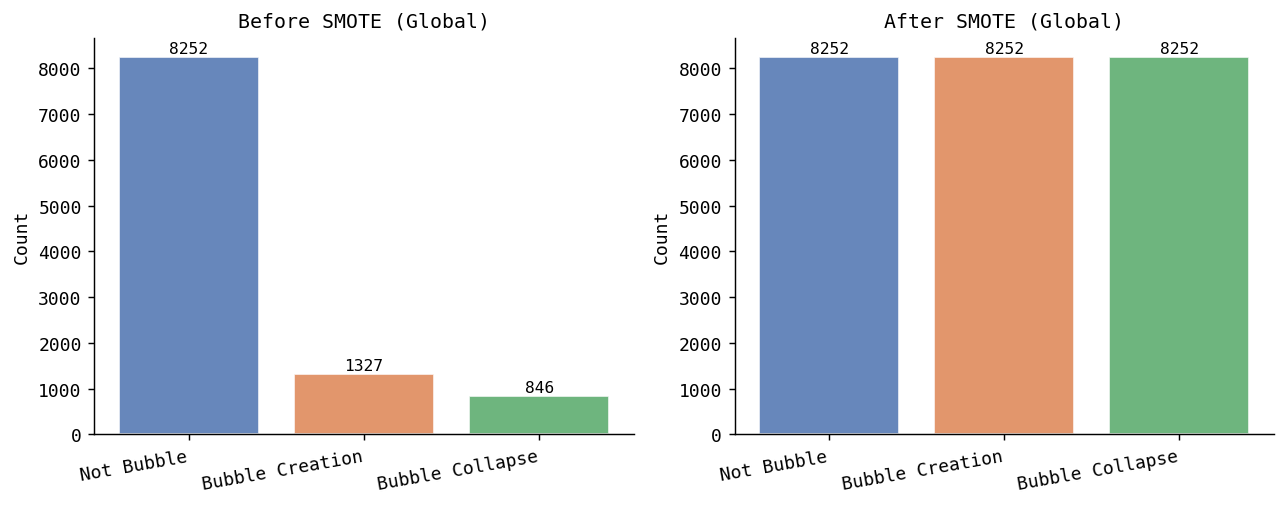


Hyperparameter tuning — Global model...
  Best CV macro-F1 : 0.9915
  Global XGBoost
                 precision    recall  f1-score   support

     Not Bubble     0.7440    1.0000    0.8532      2174
Bubble Creation     1.0000    0.0089    0.0176       674
Bubble Collapse     0.0000    0.0000    0.0000        80

       accuracy                         0.7445      2928
      macro avg     0.5813    0.3363    0.2903      2928
   weighted avg     0.7826    0.7445    0.6376      2928

  Macro F1   : 0.2903   |   Weighted F1 : 0.6376   |   ROC-AUC : 0.8112



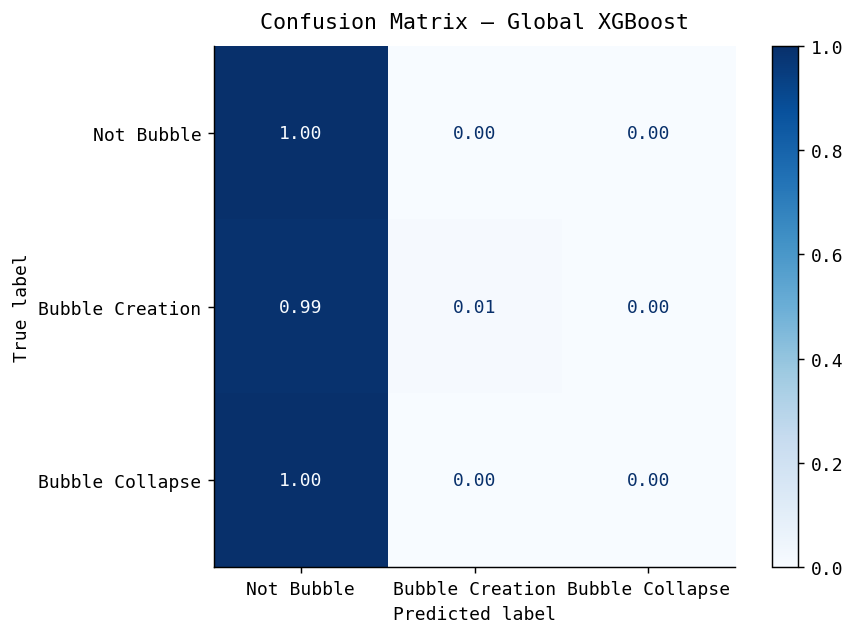

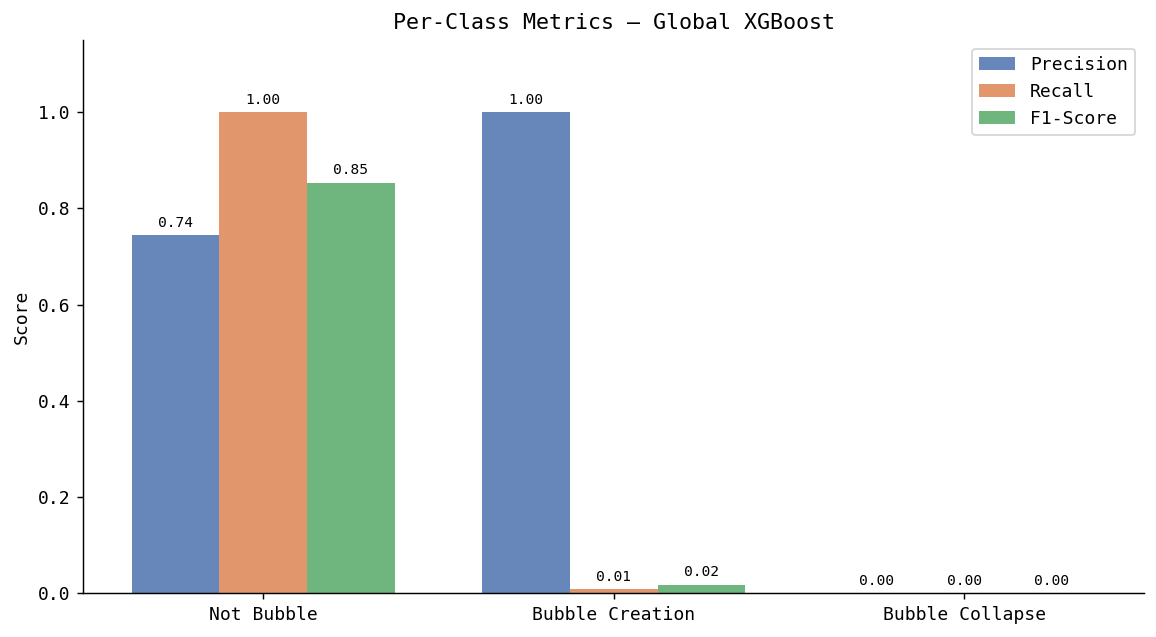

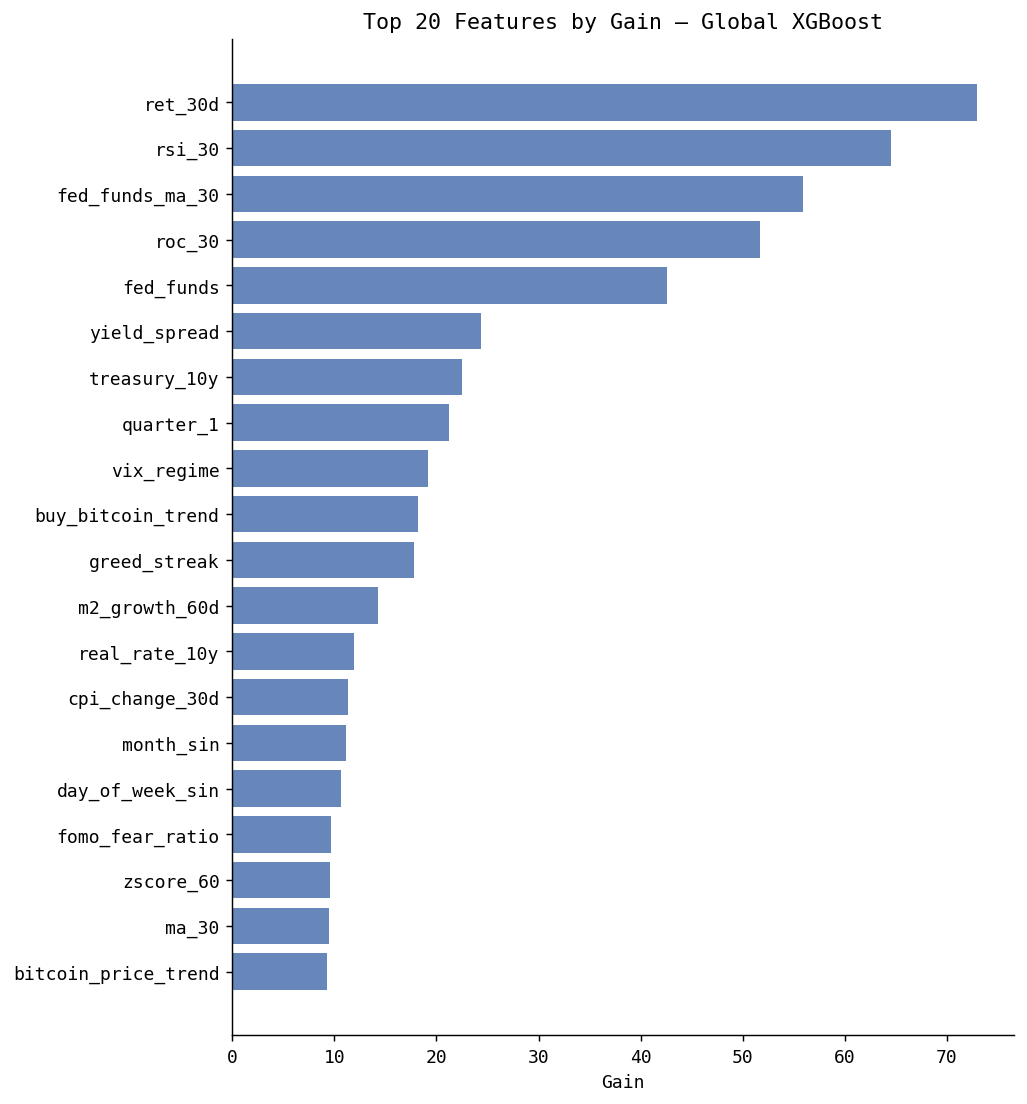


Global model — per-coin breakdown:
Coin  F1 Not Bubble  F1 Bubble Creat.  F1 Bubble Coll.  F1 Weighted
 ADA         0.9083             0.000              0.0       0.7557
 BNB         0.8504             0.000              0.0       0.6291
 BTC         0.7630             0.000              0.0       0.4706
DOGE         0.9070             0.129              0.0       0.7665
 ETH         0.9357             0.000              0.0       0.8225
 SOL         0.7242             0.000              0.0       0.4111


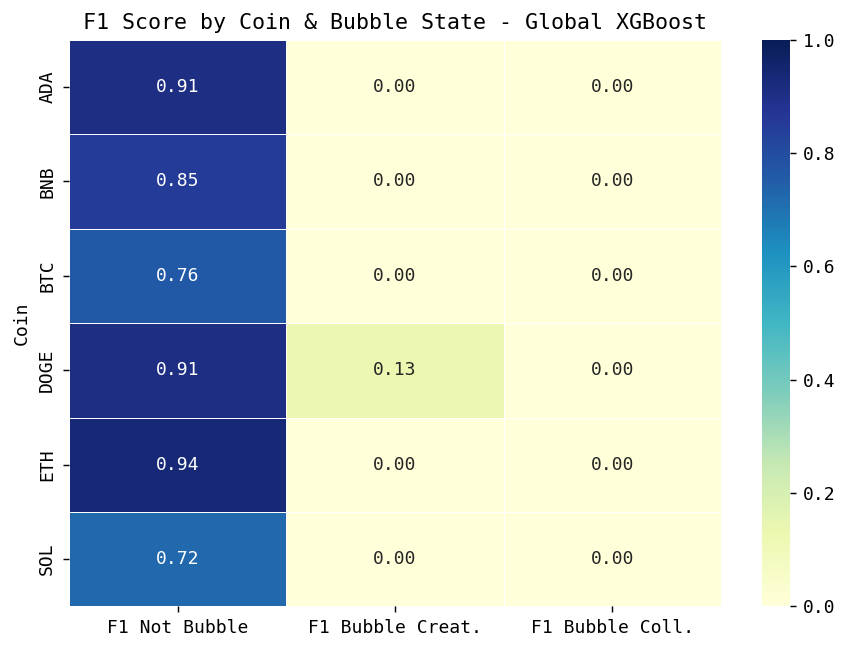


  MODEL 2: PER-COIN (separate model for each coin)

-------------------------------------------------------
  Training per-coin model : ADA
-------------------------------------------------------
  Train: 1,948  |  Test: 488  | Cut-off: 2023-08-31
SMOTE  Before: {'Not Bubble': 1535, 'Bubble Creation': 255, 'Bubble Collapse': 158}  ->  After: {'Not Bubble': 1535, 'Bubble Creation': 1535, 'Bubble Collapse': 1535}
  Best CV macro-F1 : 0.9937
  Per-Coin: ADA
  ⚠ Only 2 class(es) in test set: ['Not Bubble', 'Bubble Creation']
                 precision    recall  f1-score   support

     Not Bubble     0.8753    0.9680    0.9193       406
Bubble Creation     0.7879    0.3171    0.4522        82
Bubble Collapse     0.0000    0.0000    0.0000         0

       accuracy                         0.8586       488
      macro avg     0.5544    0.4284    0.4572       488
   weighted avg     0.8606    0.8586    0.8408       488

  Macro F1   : 0.4572   |   Weighted F1 : 0.8408   |   ROC-AUC : 0.946

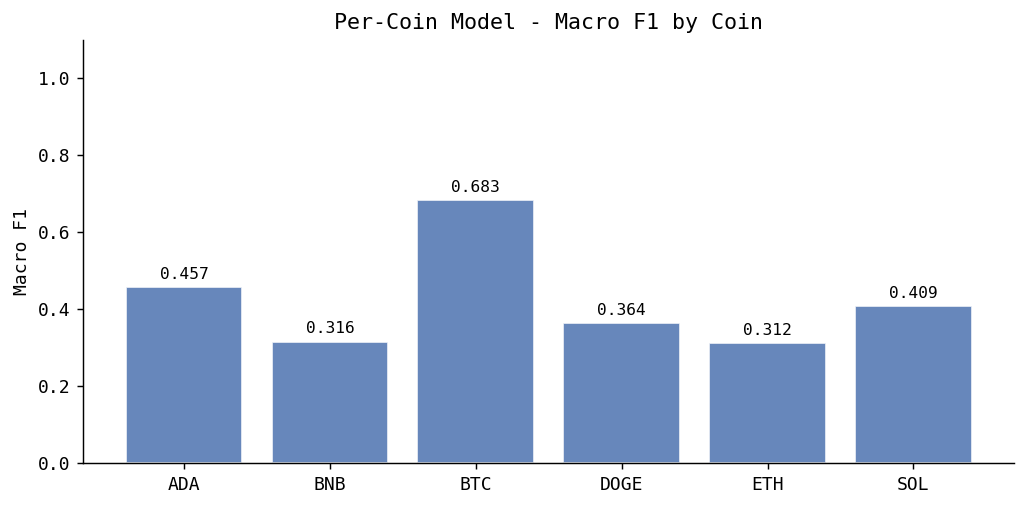

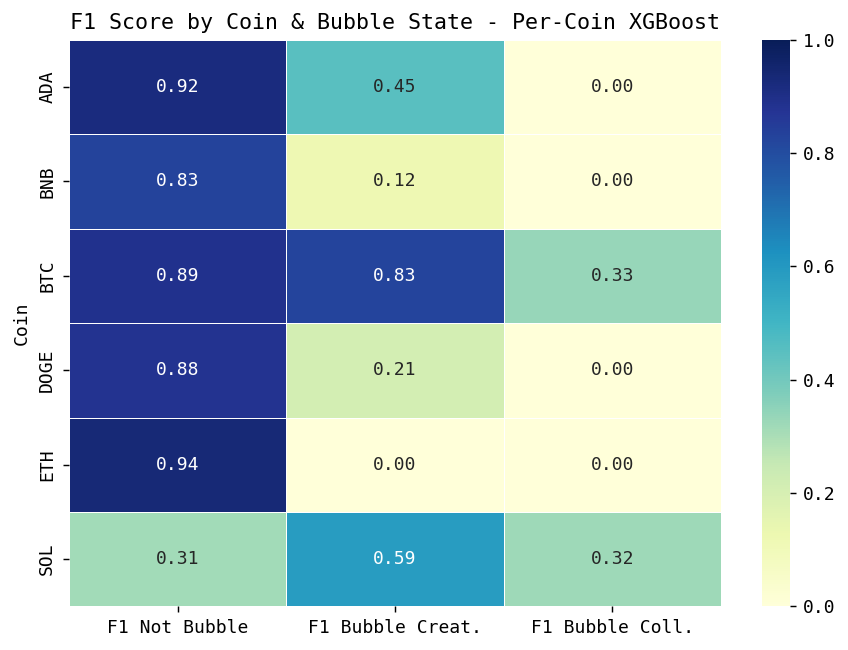

Metrics saved → xgboost_stats\model_metrics_summary.csv

  RESULTS SUMMARY
  Global Model    — Macro F1 : 0.2903  | ROC-AUC : 0.8112
  Per-Coin Models — Avg Macro F1 : 0.4236
    ADA    : Macro F1 0.4572  | ROC-AUC 0.9463
    BNB    : Macro F1 0.3163  | ROC-AUC 0.7010
    BTC    : Macro F1 0.6831  | ROC-AUC 0.9426
    DOGE   : Macro F1 0.3643  | ROC-AUC 0.7877
    ETH    : Macro F1 0.3119  | ROC-AUC 0.8197
    SOL    : Macro F1 0.4086  | ROC-AUC 0.8104

All outputs saved to xgboost_stats/


In [28]:
def main(filepath: str = "data/df_features_with_labels.csv"):
    """
    End-to-end pipeline.

    Model 1: Global XGBoost
      1. Load & preprocess all coins together
      2. Chronological train/test split (all coins share the same date cutoff)
      3. SMOTE on the combined training set
      4. Hyperparameter tuning, train, evaluate

    Model 2: Per-Coin XGBoost
      For each coin independently:
      1. Filter to that coin's rows
      2. Chronological split within the coin
      3. SMOTE on that coin's training set
      4. Hyperparameter tuning, train, evaluate
    """

    # Aesthetic header
    print("=" * 60)
    print("XGBoost Bubble Prediction Pipeline")
    print("=" * 60 + "\n")

    # 1. Load the data and preprocess (encode, impute, create lead label) 
    df = load_and_preprocess(filepath)

    # 2. MODEL 1: GLOBAL (all coins combined)
    print("\n" + "=" * 60)
    print("  MODEL 1: GLOBAL (all coins combined)")
    print("=" * 60)

    X_train, X_test, y_train, y_test, df_train, df_test = \
        temporal_train_test_split(df, test_ratio=0.2)


    smote_parts_X, smote_parts_y = [], []
    for _coin in sorted(df_train["symbol"].unique()):
        _mask = df_train["symbol"] == _coin
        _Xc, _yc = split_features_target(df_train[_mask])
        if _yc.nunique() < 2:
            smote_parts_X.append(_Xc)
            smote_parts_y.append(_yc)
            continue
        _Xr, _yr = apply_smote(_Xc, _yc, verbose=False)
        smote_parts_X.append(pd.DataFrame(_Xr, columns=_Xc.columns))
        smote_parts_y.append(pd.Series(_yr))
    X_tr_res = pd.concat(smote_parts_X, ignore_index=True)
    y_tr_res = pd.concat(smote_parts_y, ignore_index=True)
    y_before = y_train.copy()
    plot_class_distribution(y_before, y_tr_res, " (Global)")

    print("\nHyperparameter tuning — Global model...")
    global_model = hyperparameter_tuning(X_tr_res, y_tr_res, n_iter=40, cv_folds=5)
    # train_model now carves its own val set - no test set passed in
    global_model = train_model(X_tr_res, y_tr_res, global_model)
    res_global   = evaluate_model(global_model, X_test, y_test, "Global XGBoost")

    ## 2.1 Global model plots
    plot_confusion_matrix(y_test, res_global["y_pred"], "Global XGBoost")
    plot_per_class_metrics(res_global)
    plot_feature_importance(global_model, model_name="Global XGBoost", top_n=20)

    ## 2.2 Cross-asset view: how does the global model perform on each coin?
    print("\nGlobal model — per-coin breakdown:")
    df_global_coins = evaluate_per_coin(global_model, df_test, "Global XGBoost")
    print(df_global_coins.to_string(index=False))
    plot_per_coin_heatmap(df_global_coins, title="Global XGBoost")

    # 3. MODEL 2: PER-COIN MODELS
    print("\n" + "=" * 60)
    print("  MODEL 2: PER-COIN (separate model for each coin)")
    print("=" * 60)

    per_coin_models, per_coin_results, per_coin_summary = train_per_coin_models(
        df, test_ratio=0.2, n_iter=40, cv_folds=5
    )

    ## 3.1 Per-coin models plots
    plot_per_coin_model_comparison(per_coin_results)

    ## 3.2  Per-coin heatmap using each coin's own model predictions
    per_coin_f1_rows = []
    for coin, result in per_coin_results.items():
        per_coin_f1_rows.append({
            "Coin"             : coin,
            "F1 Not Bubble"    : round(result["f1_per_class"][0], 4),
            "F1 Bubble Creat." : round(result["f1_per_class"][1], 4),
            "F1 Bubble Coll."  : round(result["f1_per_class"][2], 4),
            "F1 Weighted"      : round(result["f1_weighted"],      4),
        })
    df_per_coin_f1 = pd.DataFrame(per_coin_f1_rows)
    plot_per_coin_heatmap(df_per_coin_f1, title="Per-Coin XGBoost")

    # 4. EXPORT ALL METRICS TO CSV
    all_results = [res_global] + list(per_coin_results.values())
    export_metrics_to_csv(all_results)

    # 5. FINAL SUMMARY PRINT-OUT
    print("\n" + "=" * 60)
    print("  RESULTS SUMMARY")
    print("=" * 60)
    print(f"  Global Model    — Macro F1 : {res_global['f1_macro']:.4f}  "
          f"| ROC-AUC : {res_global['roc_auc']:.4f}")
    if per_coin_results:
        avg_f1 = np.mean([r["f1_macro"] for r in per_coin_results.values()])
        print(f"  Per-Coin Models — Avg Macro F1 : {avg_f1:.4f}")
        for coin, r in per_coin_results.items():
            print(f"    {coin:<6} : Macro F1 {r['f1_macro']:.4f}  "
                  f"| ROC-AUC {r['roc_auc']:.4f}")
    print("=" * 60)
    print("\nAll outputs saved to xgboost_stats/")
    return global_model, per_coin_models


# Start the pipeline
if __name__ == "__main__":
    FILEPATH = "data/df_features_with_labels.csv"
    global_model, per_coin_models = main(FILEPATH)
